# Why vector stores

- generating embedding vectors for huge data base
- Storing all those embeddings
- Intelligent Semantic Search



A vector store is a sytem designed to store and retreive data represented numerical vectors

##### Key Features

1. Storage :  Ensure that vectors and their associated etafata are retained, whethe in memory for quick lookups or on disk durability and large scale use

2. Similarity Search :  Helps retrive the vectors most similar to a query vector

3. Indexing :  Provide a data structure or method that neables fast similarity searched in high dimentional vectors(eg, appropriate nearest neighbour lookups)

4. CRUD Operations :  Manage the lifecycle of data - adding new vectors, reading them, updating existing entries removing outdated vectors

### USE CASES
1. Semantic search
2. RAG
3. Recommender system
4. Image/Multimedia search

## VECTOR STORE vs VECTOR DATABASES

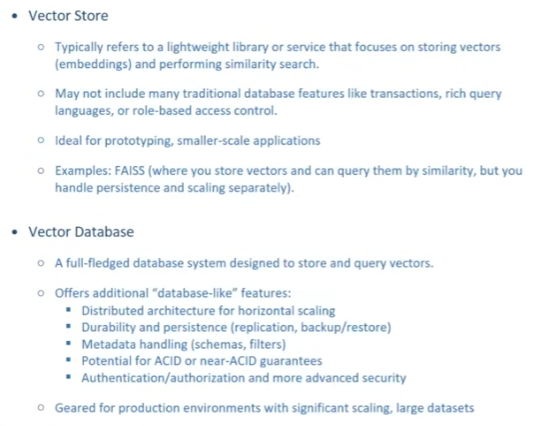

## Vector STores in LangChain

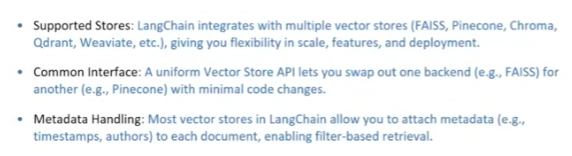

## Chroma Vector Store

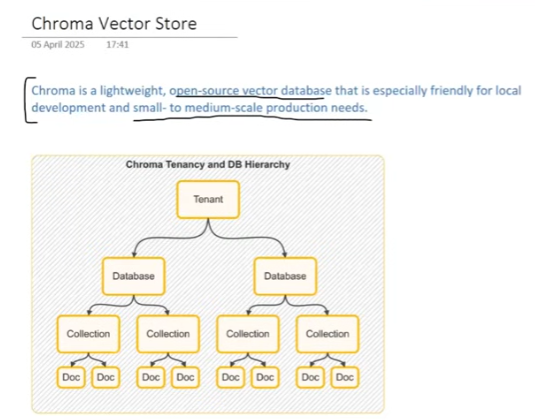

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from dotenv import load_dotenv 

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8073.96it/s]


In [14]:

vector_store = Chroma(
    embedding_function=embeddings,
    persist_directory='VectorStoreDirectory',
    collection_name='learning'
)

In [15]:
from langchain_core.documents import Document

docs = [
    Document(page_content="Virat Kohli is a great batsman."),
    Document(page_content="MS Dhoni is known for captaincy.")
]
vector_store.add_documents(docs)

['7f6516e6-6f1b-4931-a68d-aeda0a237a7f',
 '4a3a39cb-9a10-4845-8b26-e8f8a46c62d5']

In [16]:
vector_store.get(include=['embeddings', 'documents', 'metadatas'])

{'ids': ['7f6516e6-6f1b-4931-a68d-aeda0a237a7f',
  '4a3a39cb-9a10-4845-8b26-e8f8a46c62d5'],
 'embeddings': array([[ 5.71283475e-02,  7.70492479e-02, -6.71720728e-02,
         -3.69998179e-02,  9.04291868e-03,  5.67772985e-02,
          3.59656364e-02,  5.51743545e-02, -1.93832051e-02,
          4.40881550e-02, -6.72694575e-03, -6.45291582e-02,
          2.04191972e-02,  1.31628036e-01,  1.05787665e-01,
          6.75091380e-03,  6.66456670e-02,  4.41260859e-02,
          3.33281979e-02, -5.72420433e-02, -6.14273809e-02,
          1.24755166e-01,  3.25308852e-02, -4.33221310e-02,
         -3.39982286e-02, -5.69380075e-02, -6.05632504e-03,
          4.03733514e-02,  3.33220586e-02, -4.47079632e-03,
          3.99645530e-02,  2.50742193e-02, -6.51264042e-02,
          6.82088584e-02, -4.29963693e-02, -1.46327596e-02,
         -5.31751290e-02,  1.10985436e-01,  9.29895714e-02,
         -6.88764900e-02, -1.92981586e-02,  1.61509700e-02,
          1.39739998e-02,  3.42285112e-02,  2.98591014

In [17]:
vector_store.similarity_search(
    query = 'Who is the best captain?',
    k = 1
)

[Document(id='4a3a39cb-9a10-4845-8b26-e8f8a46c62d5', metadata={}, page_content='MS Dhoni is known for captaincy.')]

In [18]:
vector_store.similarity_search_with_score(
    query = 'Who is the best captain?',
    k = 1
)

[(Document(id='4a3a39cb-9a10-4845-8b26-e8f8a46c62d5', metadata={}, page_content='MS Dhoni is known for captaincy.'),
  0.92694091796875)]

In [21]:
updated_doc = Document(
    page_content = "Virat Kohli is the best batsmen of all time",
    metadata={"source": "manual_update"}
)

vector_store.update_document(
    '7f6516e6-6f1b-4931-a68d-aeda0a237a7f',
    updated_doc
)

In [ ]:
vector_store.delete(ids=[''])